In [ ]:
# ==============================================
# 🛠️ INSTALL ALL DEPENDENCIES INTO THIS KERNEL
# ==============================================
import sys

!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install \
    torch torchvision torchaudio \
    numpy pillow tqdm matplotlib seaborn scikit-learn opencv-python


In [2]:
import os, sys

# Set the project root (one level up from notebooks/)
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)


In [3]:
from src.setup.environment_mouth_extraction import verify_environment
verify_environment(project_root)


🔧 Verifying mouth extraction environment...
✅ Folder exists: data
✅ Folder exists: src
✅ Folder exists: models
✅ Folder exists: notebooks
✅ Folder exists: tests
✅ Mouth cascade file is available.
🟢 Mouth extraction environment ready.


In [4]:
from src.mouth_detection.mouth_extraction import extract_mouth_from_frames


In [5]:
video_name = "vid_001"  # Or any other video folder already processed by 01
video_dir = os.path.join(project_root, "data", video_name)


In [6]:
extract_mouth_from_frames(video_dir)


✅ Mouth crops saved for: vid_001


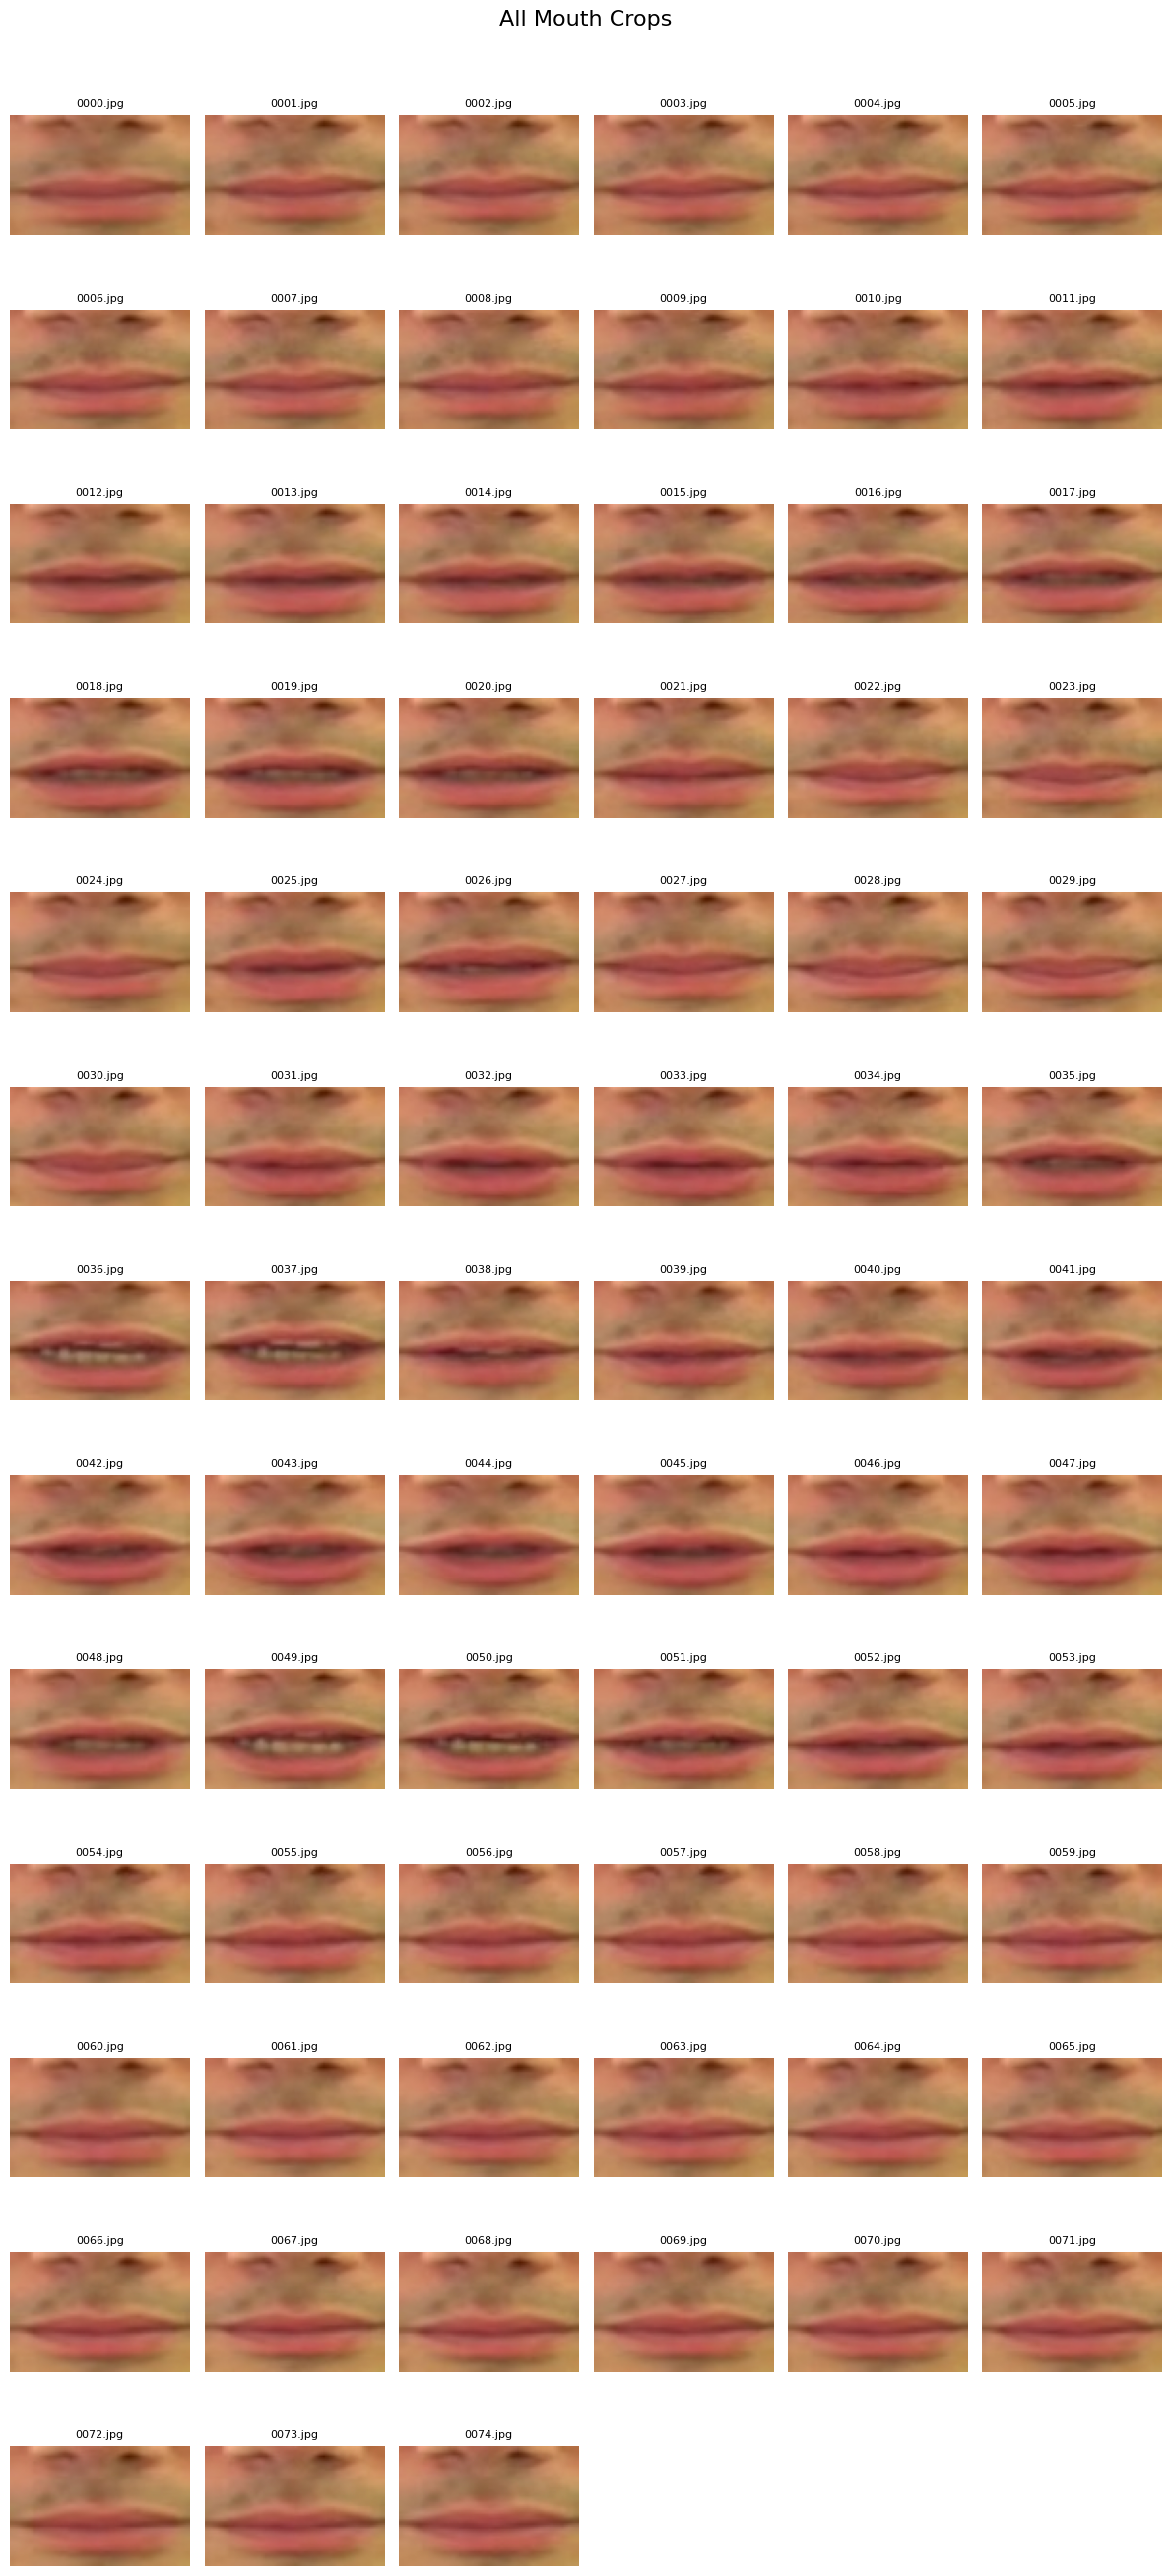

In [8]:
import matplotlib.pyplot as plt
from PIL import Image
import os

crops_path = os.path.join(video_dir, "mouth_crops")
crop_files = sorted([f for f in os.listdir(crops_path) if f.endswith(".jpg")])

num_images = len(crop_files)
cols = 6
rows = (num_images + cols - 1) // cols  # Round up

plt.figure(figsize=(cols * 2, rows * 2))
for i, f in enumerate(crop_files):
    img = Image.open(os.path.join(crops_path, f))
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f, fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.suptitle("All Mouth Crops", fontsize=16, y=1.02)
plt.show()
